<a href="https://colab.research.google.com/github/esraamorsy1/HEMAYA/blob/main/HTI(Final_Project)(CV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup

This project uses TensorFlow/Keras to build a Convolutional Neural Network (CNN)
for handwritten digit recognition. Before building the model, we import the
required libraries and verify GPU availability, since training a CNN on a GPU
is significantly faster than on a CPU.

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("GPU Available:", tf.config.list_physical_devices('GPU'))

print("TensorFlow version:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## 2. Dataset Loading

We use the MNIST dataset, a benchmark dataset in computer vision consisting of
70,000 grayscale images (28x28 pixels) of handwritten digits (0–9). It is
pre-split into 60,000 training samples and 10,000 test samples, and is loaded
directly through the Keras API.

In [10]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Number of classes:", len(np.unique(y_train)))

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Number of classes: 10


## 3. Data Exploration

Before preprocessing, we visualize a sample of the training images alongside
their corresponding labels. This step confirms that the dataset was loaded
correctly and gives an initial sense of the variability in handwriting styles
the model will need to generalize over.

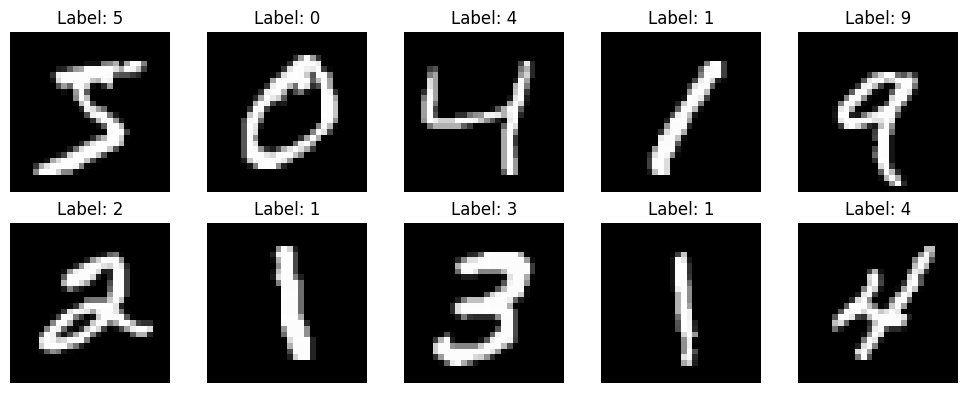

In [11]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Two preprocessing steps are applied before training:

- **Normalization**: Pixel values are rescaled from the range [0, 255] to
  [0, 1]. This improves numerical stability and speeds up convergence during
  training.
- **Reshaping**: A channel dimension is added to match the input shape expected
  by a Conv2D layer (height, width, channels). Since MNIST images are
  grayscale, the channel dimension is 1.

Labels are also converted to one-hot encoded vectors, which is the format
required for categorical cross-entropy loss.

In [12]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("New training shape:", x_train.shape)

num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

New training shape: (60000, 28, 28, 1)


## 5. Model Architecture

The model is a Convolutional Neural Network (CNN) composed of two convolutional
blocks followed by a fully connected classifier:

- **Conv2D + MaxPooling2D (x2)**: Extract spatial features from the images,
  starting with low-level features (edges) and progressing to higher-level
  patterns (shapes and strokes).
- **Flatten**: Converts the 2D feature maps into a 1D vector.
- **Dropout**: Randomly deactivates neurons during training to reduce
  overfitting.
- **Dense (Softmax)**: Outputs a probability distribution over the 10 digit
  classes.

In [13]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),


    layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Compilation

The model is compiled with:

- **Loss function**: Categorical cross-entropy, suitable for multi-class
  classification problems.
- **Optimizer**: Adam, an adaptive learning-rate optimization algorithm known
  for fast and stable convergence.
- **Metric**: Accuracy, used to monitor classification performance during
  training.

In [14]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

## 7. Model Training

The model is trained for a fixed number of epochs using mini-batch gradient
descent. A portion of the training data (10%) is held out as a validation set
to monitor generalization performance and detect overfitting during training.

In [15]:
batch_size = 128
epochs = 10

history = model.fit(
    x_train, y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8863 - loss: 0.3714 - val_accuracy: 0.9790 - val_loss: 0.0820
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9672 - loss: 0.1068 - val_accuracy: 0.9850 - val_loss: 0.0560
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9741 - loss: 0.0831 - val_accuracy: 0.9872 - val_loss: 0.0447
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9794 - loss: 0.0672 - val_accuracy: 0.9895 - val_loss: 0.0420
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9805 - loss: 0.0597 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9833 - loss: 0.0528 - val_accuracy: 0.9902 - val_loss: 0.0374
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9839 - loss: 0.0502 - val_accuracy: 0.9893 - val_loss: 0.0358
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0464 - val_accuracy: 

## 8. Model Evaluation

The trained model is evaluated on the held-out test set, which it has not seen
during training. Test accuracy and loss are reported as the final performance
metrics. Training and validation curves are also plotted to visually inspect
the learning behavior over epochs.

Test accuracy: 98.99%
Test loss: 0.0257


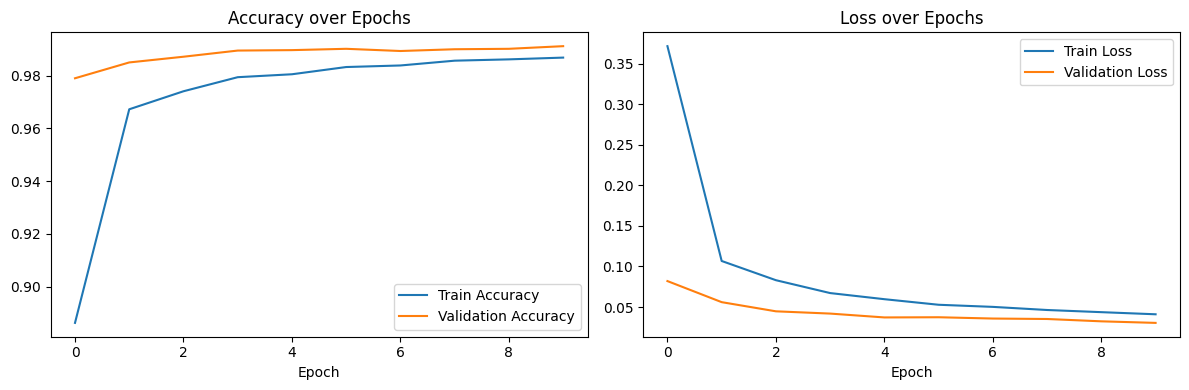

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## 9. Model Saving

The trained model is serialized and saved to disk in HDF5 (.h5) format. This
allows the model to be reloaded later without retraining, and is a prerequisite
for the next stage of the project (digit detection and the user interface).

In [17]:
model.save("digit_recognition_model.h5")
print("Model saved successfully!")

from google.colab import files
files.download("digit_recognition_model.h5")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from tensorflow.keras.models import load_model

model = load_model("digit_recognition_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [20]:
from google.colab import files
import cv2
import numpy as np

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
print("Image shape:", image.shape)

Saving sample_digits.png to sample_digits.png
Image shape: (150, 600, 3)


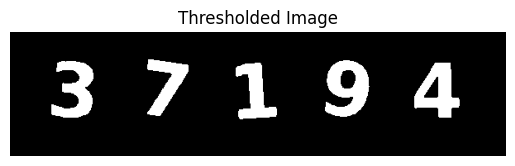

In [21]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

import matplotlib.pyplot as plt
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

In [22]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

def sort_contours(contours):
    bounding_boxes = [cv2.boundingRect(c) for c in contours]
    sorted_pairs = sorted(zip(contours, bounding_boxes), key=lambda b: b[1][0])
    return [pair[0] for pair in sorted_pairs]

contours = sort_contours(contours)
print(f"Number of digits detected: {len(contours)}")

Number of digits detected: 5


In [23]:
def extract_digit(thresh_image, contour, padding=10):
    x, y, w, h = cv2.boundingRect(contour)

    if w < 5 or h < 5:
        return None

    digit = thresh_image[y:y+h, x:x+w]

    size = max(w, h) + padding * 2
    square = np.zeros((size, size), dtype=np.uint8)
    x_offset = (size - w) // 2
    y_offset = (size - h) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = digit

    resized = cv2.resize(square, (28, 28), interpolation=cv2.INTER_AREA)

    return resized, (x, y, w, h)

digits_data = []
for contour in contours:
    result = extract_digit(thresh, contour)
    if result is not None:
        digits_data.append(result)

print(f"Successfully extracted {len(digits_data)} digits")

Successfully extracted 5 digits


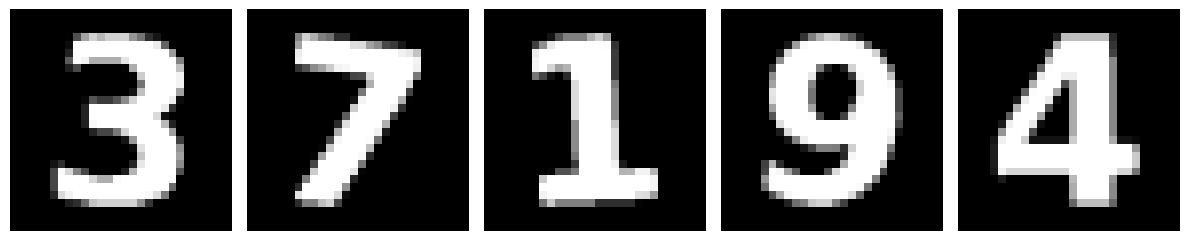

In [24]:
plt.figure(figsize=(12, 3))
for i, (digit_img, box) in enumerate(digits_data):
    plt.subplot(1, len(digits_data), i + 1)
    plt.imshow(digit_img, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
predictions = []

for digit_img, box in digits_data:
    normalized = digit_img.astype("float32") / 255.0
    input_img = np.expand_dims(normalized, axis=(0, -1))  # الشكل: (1, 28, 28, 1)

    pred = model.predict(input_img, verbose=0)
    predicted_digit = np.argmax(pred)
    confidence = np.max(pred)

    predictions.append((predicted_digit, confidence, box))

for digit, conf, box in predictions:
    print(f"Predicted: {digit} | Confidence: {conf*100:.1f}%")

Predicted: 3 | Confidence: 100.0%
Predicted: 7 | Confidence: 90.3%
Predicted: 1 | Confidence: 98.5%
Predicted: 9 | Confidence: 99.0%
Predicted: 4 | Confidence: 97.0%


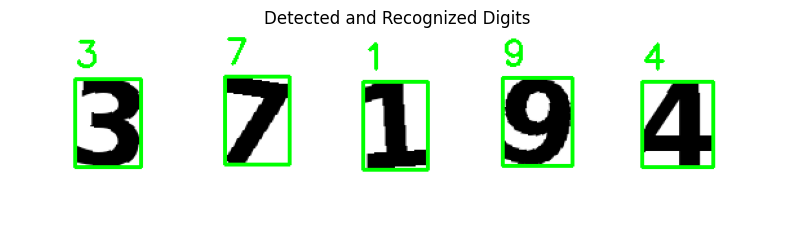

In [26]:
output_image = image.copy()

for digit, conf, (x, y, w, h) in predictions:
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(output_image, str(digit), (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

output_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(output_rgb)
plt.axis('off')
plt.title("Detected and Recognized Digits")
plt.show()